# Predicting Titanic Passenger Survival Using Decision Tree Machine Learning

## Research Question
Can passenger demographic and travel-related characteristics predict survival in the Titanic disaster using a Decision Tree Machine Learning Algorithm?



## Importing Libraries

This section imports the necessary libraries for:

- Data manipulation using Pandas and NumPy
- Data visualization using Matplotlib and Seaborn
- Building the Decision Tree model using Scikit-learn
- Evaluating model performance using accuracy metrics and confusion matrix

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# preprocessing
from sklearn.preprocessing import LabelEncoder

## Loading the Dataset

The Titanic dataset is loaded into a Pandas DataFrame to allow inspection, cleaning, and analysis.

In [2]:
df = pd.read_csv('titanic.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Overview

This section examines:

- Number of rows and columns
- Data types
- Missing values
- Statistical summaries

Understanding the structure of the data helps identify preprocessing requirements.

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Cleaning and Validation
Missing Value Handling

In [4]:
df['Age'] = df['Age'].fillna(
    df['Age'].median()
)

df['Embarked'].fillna(
    df['Embarked'].mode()[0],
    inplace=True
)

df.drop(columns=['Cabin'], inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_14120\1690484266.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Embarked'].fillna(


## Missing Value Handling

This section performs data cleaning to address missing values and remove irrelevant features.

### 1. Handling Missing Values in Age

```python
df['Age'] = df['Age'].fillna(
    df['Age'].median()
)
```

Missing values in the `Age` column were replaced using the **median age**. The median was selected because it is less sensitive to outliers and provides a more reliable representation of central tendency for numerical data.

### 2. Handling Missing Values in Embarked

```python
df['Embarked'].fillna(
    df['Embarked'].mode()[0],
    inplace=True
)
```

Missing values in the `Embarked` column were replaced using the **mode**, which represents the most frequently occurring category. Since `Embarked` is a categorical variable, mode imputation is appropriate.

### 3. Removing the Cabin Column

```python
df.drop(columns=['Cabin'], inplace=True)
```

The `Cabin` column was removed because it contained a large number of missing values, which could negatively affect model performance and introduce unnecessary complexity.

The parameter `inplace=True` means that the operation is applied **directly to the original DataFrame** without needing to assign the result to a new variable.

For example:

```python
df.drop(columns=['Cabin'], inplace=True)
```

This permanently removes the `Cabin` column from `df`.

Without `inplace=True`, the operation creates a modified copy, so reassignment is required:

```python
df = df.drop(columns=['Cabin'])
```

Both approaches achieve the same result, but `inplace=True` updates the existing DataFrame immediately.

In this notebook, `inplace=True` is used to simplify preprocessing steps by modifying the dataset directly.

Remove irrelevant features

In [5]:
df.drop(
    columns=['Name', 'Ticket', 'PassengerId'],
    inplace=True
)

Encode Categorical Variables

In [6]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

## Encoding Categorical Variables

This section converts categorical (text-based) variables into numerical values so they can be processed by the Decision Tree Machine Learning algorithm.

### 1. Initializing the Label Encoder

```python
le = LabelEncoder()
```

The `LabelEncoder()` function from Scikit-learn is initialized to transform categorical text values into numeric labels.

Machine learning algorithms generally require numerical input; therefore, categorical variables such as `Sex` and `Embarked` must be encoded.

### 2. Encoding the `Sex` Column

```python
df['Sex'] = le.fit_transform(df['Sex'])
```

The `Sex` column, which originally contains text values:

- `male`
- `female`

is converted into numerical labels:

- `female = 0`
- `male = 1`

This transformation enables the machine learning model to interpret gender as a numerical feature.

### 3. Encoding the `Embarked` Column

```python
df['Embarked'] = le.fit_transform(df['Embarked'])
```

The `Embarked` column, which contains passenger embarkation ports:

- `C = Cherbourg`
- `Q = Queenstown`
- `S = Southampton`

is transformed into numeric values such as:

- `C = 0`
- `Q = 1`
- `S = 2`

The exact numeric mapping may vary depending on the alphabetical ordering detected by `LabelEncoder`.

### Understanding `fit_transform()`

The method:

```python
fit_transform()
```

performs two operations:

1. **Fit** – identifies the unique categories in the column.
2. **Transform** – converts those categories into numerical labels.

For example:

```python
['female', 'male', 'female']
```

becomes:

```python
[0, 1, 0]
```

This preprocessing step ensures categorical data can be used effectively during model training.

Validation

In [7]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

## Data Cleaning and Validation

The following preprocessing steps were performed:

1. Missing values in Age were replaced using the median.
2. Missing values in Embarked were replaced using the mode.
3. Cabin was removed due to excessive missing values.
4. Irrelevant identifiers were removed.
5. Categorical variables were encoded numerically.

After preprocessing, validation confirmed that no missing values remained.

## EDA

Survival Distribution

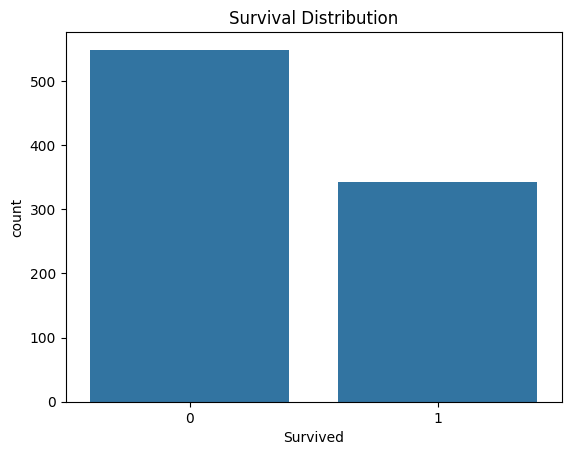

In [10]:
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution')
plt.show()

### Interpretation

The visualization shows the distribution of survivors and non-survivors. A class imbalance may affect model learning and should be considered during evaluation.

Gender vs Survival

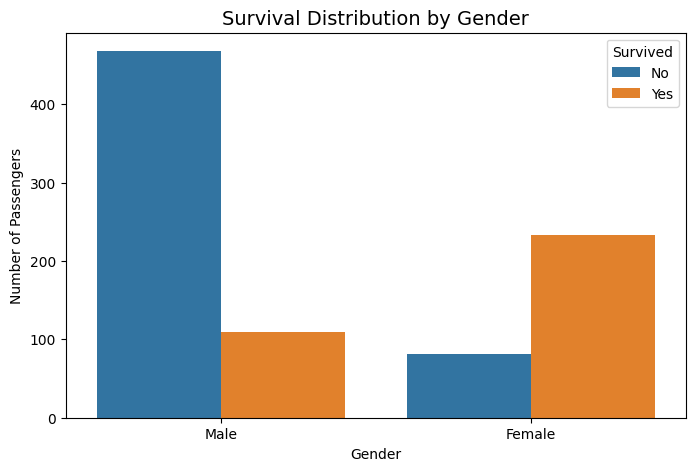

In [14]:
df['Gender'] = df['Sex'].map({
    0: 'Female',
    1: 'Male'
})

plt.figure(figsize=(8,5))

sns.countplot(
    x='Gender',
    hue='Survived',
    data=df
)

plt.title(
    'Survival Distribution by Gender',
    fontsize=14
)

plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.legend(
    title='Survived',
    labels=['No', 'Yes']
)

plt.show()

### Interpretation

The visualization suggests that survival differs by gender. Female passengers appear to have a higher survival rate than male passengers.

Correlation Heatmap

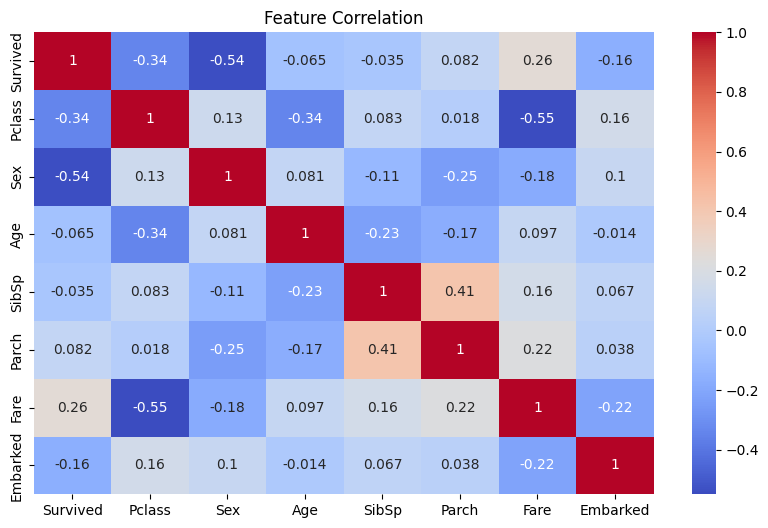

In [16]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation')
plt.show()

### Interpretation

Correlation analysis helps identify relationships among variables and their association with the target variable (Survived).

## Feature Importance

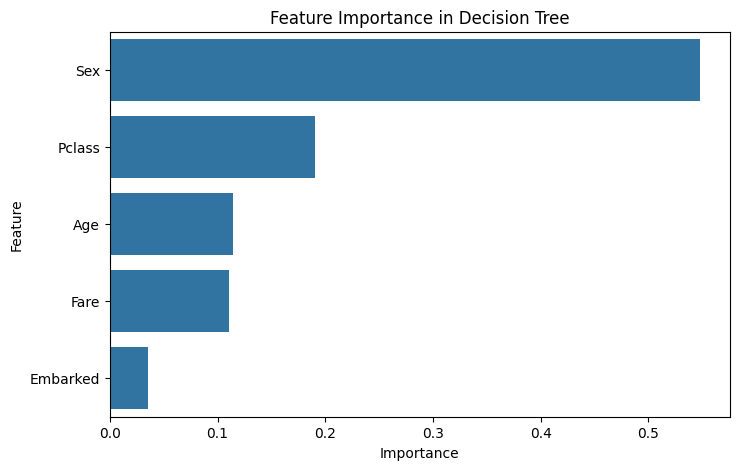

    Feature  Importance
1       Sex    0.548137
0    Pclass    0.190666
2       Age    0.114843
3      Fare    0.110974
4  Embarked    0.035380


In [25]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Feature Importance in Decision Tree'
)

plt.show()

print(importance)

## Feature Selection

Feature selection was conducted using correlation analysis to identify variables associated with passenger survival.

Based on the correlation matrix:

- Sex demonstrated the strongest relationship with survival.
- Passenger class (Pclass) showed a moderate negative relationship.
- Fare exhibited a moderate positive relationship.
- Embarked and Age showed weaker but potentially meaningful predictive value.

Variables such as SibSp and Parch were excluded due to their weak relationship with the target variable and limited contribution to model interpretability.

In [18]:
X = df[
    [
        'Pclass',
        'Sex',
        'Age',
        'Fare',
        'Embarked'
    ]
]


y = df['Survived']

print(X.head())

   Pclass  Sex   Age     Fare  Embarked
0       3    1  22.0   7.2500         2
1       1    0  38.0  71.2833         0
2       3    0  26.0   7.9250         2
3       1    0  35.0  53.1000         2
4       3    1  35.0   8.0500         2


## Modelling

Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Why stratify=y?

This keeps the same proportion of survivors and non-survivors in training and testing sets, improving evaluation reliability.

## Splitting the Dataset into Training and Testing Sets

This section divides the dataset into **training data** and **testing data** to evaluate the performance of the Decision Tree model.

```python
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
```

### Purpose of Dataset Splitting

The dataset is divided into two subsets:

- **Training Set (`X_train`, `y_train`)** – used to train the machine learning model.
- **Testing Set (`X_test`, `y_test`)** – used to evaluate the model’s predictive performance on unseen data.

This approach helps determine whether the model generalizes effectively and prevents overfitting.

### Explanation of Parameters

#### `X`

```python
X
```

Represents the **independent variables (features)** used to predict survival.

Examples include:

- Passenger class (`Pclass`)
- Gender (`Sex`)
- Age
- Fare
- Embarkation port (`Embarked`)

#### `y`

```python
y
```

Represents the **dependent variable (target)**, which is:

```python
Survived
```

This is the value the model attempts to predict.

#### `test_size=0.20`

```python
test_size=0.20
```

Allocates **20% of the dataset for testing** and **80% for training**.

For example:

- **80%** → model training
- **20%** → model evaluation

This ratio is commonly used in machine learning to ensure sufficient training data while retaining enough testing data for reliable evaluation.

#### `random_state=42`

```python
random_state=42
```

Sets a fixed random seed to ensure **reproducibility**.

This means the dataset will be split in the same way each time the notebook is executed, allowing consistent experimental results.

#### `stratify=y`

```python
stratify=y
```

Ensures that the proportion of survival classes (`Survived = 0` and `Survived = 1`) remains balanced in both training and testing datasets.

This prevents class imbalance issues and improves the reliability of model evaluation.

For example:

If the original dataset contains:

- 60% non-survivors
- 40% survivors

then both training and testing sets will maintain approximately the same distribution.

## Decision Tree Model Training

A Decision Tree classifier was trained using the Gini impurity criterion.

Hyperparameters such as maximum depth and minimum samples per split were adjusted to reduce overfitting and improve generalization performance.

In [20]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

## Decision Tree Model Initialization

This section initializes the **Decision Tree Classifier**, which will be used to predict passenger survival based on selected features.

```python
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
```

### Purpose of the Decision Tree Classifier

A **Decision Tree** is a supervised machine learning algorithm used for **classification problems**. It predicts outcomes by splitting data into decision rules based on feature values.

In this study, the model predicts whether a passenger **survived (`1`) or did not survive (`0`)**.

### Explanation of Parameters

#### `criterion='gini'`

```python
criterion='gini'
```

Specifies the method used to evaluate the quality of splits in the tree.

The **Gini Impurity** measures how mixed the classes are within a node.

- Lower Gini value → better separation
- Higher Gini value → more mixed classes

The algorithm selects splits that reduce impurity and improve classification accuracy.

#### `max_depth=5`

```python
max_depth=5
```

Limits the maximum depth of the decision tree to **5 levels**.

This helps prevent **overfitting**, where the model memorizes training data instead of learning meaningful patterns.

A controlled depth improves the model’s ability to generalize to unseen data.

#### `min_samples_split=10`

```python
min_samples_split=10
```

Defines the **minimum number of samples required to split a node**.

A node must contain at least **10 observations** before it can be divided into smaller branches.

This reduces unnecessary splitting and helps improve model stability.

#### `min_samples_leaf=5`

```python
min_samples_leaf=5
```

Specifies the **minimum number of samples required in a terminal leaf node**.

Each final node must contain at least **5 observations**, helping avoid overly specific rules that may lead to overfitting.

#### `random_state=42`

```python
random_state=42
```

Sets a fixed random seed to ensure **reproducibility**.

This guarantees that the model generates consistent results each time the notebook is executed.

### Why These Parameters Were Used

These hyperparameters were selected to balance:

- **Model accuracy**
- **Interpretability**
- **Overfitting prevention**

The goal is to create a Decision Tree that is sufficiently complex to identify survival patterns while remaining interpretable and generalizable.

# Prediction

In [21]:
y_pred = model.predict(X_test)

## Performance Evaluation

In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f'Accuracy: {accuracy:.2%}'
)

Accuracy: 75.42%


## Model Evaluation

The confusion matrix demonstrates the model's classification performance by comparing predicted and actual survival outcomes.

The Decision Tree model was evaluated using:

- Accuracy
- Precision
- Recall
- F1-score

These metrics assess the effectiveness of the model in predicting passenger survival.

Accuracy  : 75.42%
Precision : 71.93%
Recall    : 59.42%
F1-Score  : 65.08%


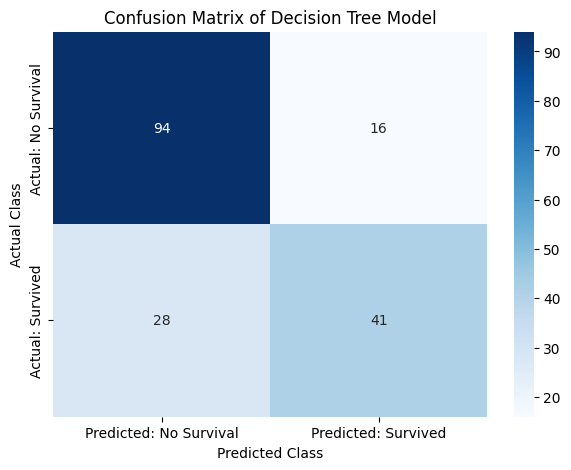

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print metrics
print(f'Accuracy  : {accuracy:.2%}')
print(f'Precision : {precision:.2%}')
print(f'Recall    : {recall:.2%}')
print(f'F1-Score  : {f1:.2%}')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Predicted: No Survival',
        'Predicted: Survived'
    ],
    yticklabels=[
        'Actual: No Survival',
        'Actual: Survived'
    ]
)

plt.title(
    'Confusion Matrix of Decision Tree Model'
)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.show()

In [28]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Actual Value': y_test.values,
    'Predicted Value': y_pred
})

# Add interpretation column
comparison_df['Result'] = np.where(
    comparison_df['Actual Value'] ==
    comparison_df['Predicted Value'],
    'Correct',
    'Incorrect'
)

# Display first 20 rows
comparison_df.head(20)

,Actual Value,Predicted Value,Result
0,0,0,Correct
1,0,0,Correct
2,1,0,Incorrect
3,0,0,Correct
4,1,1,Correct
5,1,0,Incorrect
6,1,1,Correct
7,0,1,Incorrect
8,0,0,Correct
9,0,0,Correct
